<a href="https://colab.research.google.com/github/odeandialamsyah/GAT_Hx_Ils/blob/main/Hx_ILs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch-geometric rdkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 51.2 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from torch.utils.data import DataLoader as TorchDataLoader
from rdkit import Chem
from rdkit.Chem import rdchem

from torch_geometric.nn import (
    GCNConv,
    GINEConv,
    global_mean_pool,
    global_add_pool
)

In [ ]:
#Set Seed
import random

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive/')
folder_drive = '/content/drive/MyDrive/Henry_constant'

Mounted at /content/drive/


[17:43:34] DEPRECATION WARNING: please use MorganGenerator
[17:43:34] DEPRECATION WARNING: please use MorganGenerator
[17:43:34] DEPRECATION WARNING: please use MorganGenerator
[17:43:34] DEPRECATION WARNING: please use MorganGenerator
[17:43:34] DEPRECATION WARNING: please use MorganGenerator
[17:43:34] DEPRECATION WARNING: please use MorganGenerator
[17:43:34] DEPRECATION WARNING: please use MorganGenerator
[17:43:34] DEPRECATION WARNING: please use MorganGenerator
[17:43:34] DEPRECATION WARNING: please use MorganGenerator
[17:43:34] DEPRECATION WARNING: please use MorganGenerator
[17:43:34] DEPRECATION WARNING: please use MorganGenerator
[17:43:34] DEPRECATION WARNING: please use MorganGenerator
[17:43:34] DEPRECATION WARNING: please use MorganGenerator
[17:43:34] DEPRECATION WARNING: please use MorganGenerator
[17:43:34] DEPRECATION WARNING: please use MorganGenerator
[17:43:34] DEPRECATION WARNING: please use MorganGenerator
[17:43:34] DEPRECATION WARNING: please use MorganGenerat

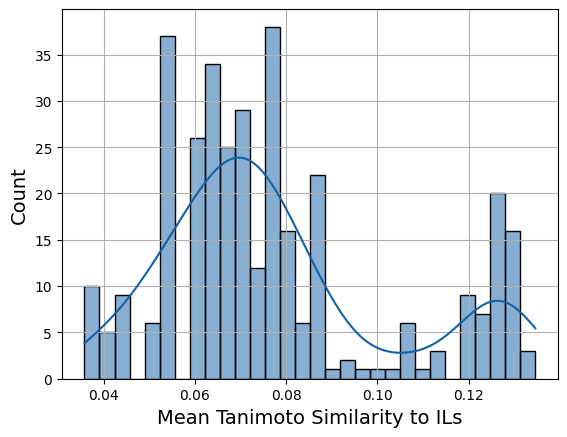

In [ ]:
# OPTIONAL
# dipakai nanti untuk chemical space analysis
def compute_tanimoto(smiles1, smiles2):
    mols1 = [Chem.MolFromSmiles(sm) for sm in smiles1]
    mols2 = [Chem.MolFromSmiles(sm) for sm in smiles2]

    fps1 = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in mols1]
    fps2 = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in mols2]

    scores = []
    for fp in fps2:
        similarities = [DataStructs.FingerprintSimilarity(fp, fp_ref) for fp_ref in fps1]
        scores.append(np.mean(similarities))

    return scores

df_ils = pd.read_excel(f"{folder_drive}/Hx_ILs.xlsx")
df_dess = pd.read_excel(f"{folder_drive}/Hx_DESs.xlsx")


df_ils["Tanimoto_to_DESs"] = compute_tanimoto(df_dess["SMILES_DES"].dropna().tolist(), df_ils["SMILES_IL"].dropna().tolist())


sns.histplot(df_ils["Tanimoto_to_DESs"], bins=30, kde=True, color="#cc191e")
plt.xlabel("Mean Tanimoto Similarity to DESs", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.grid()
plt.show()

lower, upper = 0.2, 0.55
selected_ils = df_ils[(df_ils["Tanimoto_to_DESs"] >= lower) & (df_ils["Tanimoto_to_DESs"] <= upper)]

while selected_ils.empty and lower > 0.1:
    lower -= 0.1
    upper += 0.1
    selected_ils = df_ils[(df_ils["Tanimoto_to_DESs"] >= lower) & (df_ils["Tanimoto_to_DESs"] <= upper)]

In [ ]:
#ILs dataset

In [ ]:
df_ils = pd.read_excel(f"{folder_drive}/Hx_ILs.xlsx")

df_ils = df_ils.dropna(
    subset=[
        "SMILES_cation",
        "SMILES_anion",
        "T (K)",
        "Henry's Constant H (MPa)",
        "SMILES_IL"
    ]
)

# =========================
# Temperature Scaling
# =========================
T_mean = df_ils["T (K)"].mean()
T_std = df_ils["T (K)"].std()

df_ils["T_scaled"] = (
    df_ils["T (K)"] - T_mean
) / T_std

# =========================
# Log Target
# =========================
df_ils["log_Hx"] = np.log1p(
    df_ils["Henry's Constant H (MPa)"]
)

df_ils.head()

,N,Cation(full name),Anion(full name),SMILES_cation,SMILES_anion,SMILES_IL,Canonical,IL(abbreviation),T (K),Henry's Constant H (MPa),References,T_scaled,log_Hx
0,2,1-ethyl-3-methyl-imidazolium,Tetrafluoroborate,C(C)N1C=[N+](C=C1)C,F[B-](F)(F)F,C(C)N1C=[N+](C=C1)C.F[B-](F)(F)F,CCn1cc[n+](C)c1.F[B-](F)(F)F,[EMIM][BF4],313.15,10.00,https://doi.org/10.1021/ie0704142,-0.225780,2.397895
1,4,1-hexyl-3-methyl-imidazolium,Bis(trifluoromethylsulfonyl)imide,C(CCCCC)N1C=[N+](C=C1)C,[N-](S(=O)(=O)C(F)(F)F)S(=O)(=O)C(F)(F)F,C(CCCCC)N1C=[N+](C=C1)C.[N-](S(=O)(=O)C(F)(F)F...,CCCCCCn1cc[n+](C)c1.O=S(=O)([N-]S(=O)(=O)C(F)(...,[HMIM][Tf2N],333.15,4.56,https://doi.org/10.1021/jp071897q,0.298069,1.715598
2,5,1-butyl-3-methyl-imidazolium,Hexafluorophosphate,C(CCC)N1C=[N+](C=C1)C,F[P-](F)(F)(F)(F)F,C(CCC)N1C=[N+](C=C1)C.F[P-](F)(F)(F)(F)F,CCCCn1cc[n+](C)c1.F[P-](F)(F)(F)(F)F,[BMIM][PF6],333.15,8.13,https://doi.org/10.1021/jp071897q,0.298069,2.211566
3,6,1-butyl-3-methyl-imidazolium,Bis(trifluoromethylsulfonyl)imide,C(CCC)N1C=[N+](C=C1)C,[N-](S(=O)(=O)C(F)(F)F)S(=O)(=O)C(F)(F)F,C(CCC)N1C=[N+](C=C1)C.[N-](S(=O)(=O)C(F)(F)F)S...,CCCCn1cc[n+](C)c1.O=S(=O)([N-]S(=O)(=O)C(F)(F)...,[BMIM][Tf2N],303.15,4.20,https://doi.org/10.1021/ie070501u,-0.487704,1.648659
4,7,1-pentyl-3-methyl-imidazolium,Bis(trifluoromethylsulfonyl)imide,C(CCCC)N1C=[N+](C=C1)C,[N-](S(=O)(=O)C(F)(F)F)S(=O)(=O)C(F)(F)F,C(CCCC)N1C=[N+](C=C1)C.[N-](S(=O)(=O)C(F)(F)F)...,CCCCCn1cc[n+](C)c1.O=S(=O)([N-]S(=O)(=O)C(F)(F...,[C5MIM][Tf2N],343.15,6.03,https://doi.org/10.1016/j.supflu.2008.10.012,0.559994,1.950187


In [ ]:
#FEATURE MATRIX

In [ ]:
def atom_features(atom):

    return [

        # Atomic number
        atom.GetAtomicNum(),

        # Number of bonded neighbors
        atom.GetDegree(),

        # Formal charge
        atom.GetFormalCharge(),

        # Hybridization
        int(atom.GetHybridization()),

        # Aromaticity
        int(atom.GetIsAromatic()),

        # Total hydrogens
        atom.GetTotalNumHs(),

        # Total valence
        atom.GetTotalValence(),

        # Ring membership
        int(atom.IsInRing())
    ]

In [ ]:
def bond_features(bond):

    bond_type = bond.GetBondType()

    return [

        bond.GetBondTypeAsDouble(),

        int(bond_type == rdchem.BondType.SINGLE),
        int(bond_type == rdchem.BondType.DOUBLE),
        int(bond_type == rdchem.BondType.TRIPLE),
        int(bond_type == rdchem.BondType.AROMATIC),

        int(bond.GetIsConjugated()),
        int(bond.IsInRing())
    ]

In [ ]:
#SMILES TO GRAPH

In [ ]:
def smiles_to_graph(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
      raise ValueError(f"Invalid SMILES: {smiles}")

    x = []

    for atom in mol.GetAtoms():
        x.append(atom_features(atom))

    edge_index = []
    edge_attr = []

    for bond in mol.GetBonds():

        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()

        edge_index.append([i, j])
        edge_index.append([j, i])

        edge_attr.append(bond_features(bond))
        edge_attr.append(bond_features(bond))

    x = torch.tensor(x, dtype=torch.float)

    edge_index = torch.tensor(
        edge_index,
        dtype=torch.long
    ).t().contiguous()

    edge_attr = torch.tensor(
        edge_attr,
        dtype=torch.float
    )

    return x, edge_index, edge_attr

In [ ]:
#TEST GRAPH

In [ ]:
sample_smiles = df_ils.iloc[0]["SMILES_cation"]

x, edge_index, edge_attr = smiles_to_graph(sample_smiles)

print("Node feature:", x.shape)
print("Edge index:", edge_index.shape)
print("Edge feature:", edge_attr.shape)

Node feature: torch.Size([8, 8])
Edge index: torch.Size([2, 16])
Edge feature: torch.Size([16, 7])


In [ ]:
#GRAPH Dataset

In [ ]:
graph_dataset = []

for idx, row in df_ils.iterrows():

    x_cat, edge_cat, edge_attr_cat = smiles_to_graph(
        row["SMILES_cation"]
    )

    x_an, edge_an, edge_attr_an = smiles_to_graph(
        row["SMILES_anion"]
    )

    sample = {

        # Cation graph
        "x_cat": x_cat,
        "edge_cat": edge_cat,
        "edge_attr_cat": edge_attr_cat,

        # Anion graph
        "x_an": x_an,
        "edge_an": edge_an,
        "edge_attr_an": edge_attr_an,

        # Scaled temperature
        "temperature": torch.tensor(
            [[row["T_scaled"]]],
            dtype=torch.float
        ),

        # Training target: log(Hx)
        "y": torch.tensor(
            [[row["log_Hx"]]],
            dtype=torch.float
        ),

        # Original target for evaluation
        "y_original": torch.tensor(
            [[row["Henry's Constant H (MPa)"]]],
            dtype=torch.float
        ),

        # Group label for strict split
        "group": row["SMILES_IL"]
    }

    graph_dataset.append(sample)

print("Total graph samples:", len(graph_dataset))

Total graph samples: 311


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv, GATv2Conv

import torch.nn as nn

class DualGCNModel(nn.Module):

    def __init__(self):

        super(DualGCNModel, self).__init__()

        # CATION ENCODER
        self.cat_conv1 = GCNConv(8, 64)
        self.cat_conv2 = GCNConv(64, 64)

        # ANION ENCODER
        self.an_conv1 = GCNConv(8, 64)
        self.an_conv2 = GCNConv(64, 64)

        # FUSION
        self.fc1 = nn.Linear(129, 64)
        self.fc2 = nn.Linear(64, 1)

    def encode_graph(self, x, edge_index, conv1, conv2):

        x = conv1(x, edge_index)
        x = F.relu(x)

        x = conv2(x, edge_index)
        x = F.relu(x)

        # GLOBAL POOLING
        x = x.mean(dim=0, keepdim=True)

        return x

    def forward(self, sample):

        # CATION
        x_cat = sample["x_cat"].to(device)
        edge_cat = sample["edge_cat"].to(device)

        # ANION
        x_an = sample["x_an"].to(device)
        edge_an = sample["edge_an"].to(device)

        # TEMPERATURE
        temperature = sample["temperature"].to(device)

        # ENCODE
        cat_embedding = self.encode_graph(
            x_cat,
            edge_cat,
            self.cat_conv1,
            self.cat_conv2
        )

        an_embedding = self.encode_graph(
            x_an,
            edge_an,
            self.an_conv1,
            self.an_conv2
        )

        # FUSION
        x = torch.cat(
            [
                cat_embedding,
                an_embedding,
                temperature
            ],
            dim=1
        )

        x = self.fc1(x)
        x = F.relu(x)

        x = self.fc2(x)

        return x


class ImprovedDualGCN(nn.Module):

    def __init__(self):

        super(ImprovedDualGCN, self).__init__()

        hidden_dim = 128

        # =========================
        # CATION GCN
        # =========================
        self.cat_conv1 = GCNConv(8, hidden_dim)
        self.cat_conv2 = GCNConv(hidden_dim, hidden_dim)
        self.cat_conv3 = GCNConv(hidden_dim, hidden_dim)

        # =========================
        # ANION GCN
        # =========================
        self.an_conv1 = GCNConv(8, hidden_dim)
        self.an_conv2 = GCNConv(hidden_dim, hidden_dim)
        self.an_conv3 = GCNConv(hidden_dim, hidden_dim)

        # =========================
        # FUSION MLP
        # =========================
        self.fc1 = nn.Linear(hidden_dim * 2 + 1, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)

    def encode_graph(
        self,
        x,
        edge_index,
        conv1,
        conv2,
        conv3
    ):

        # Layer 1
        x = conv1(x, edge_index)
        x = F.relu(x)

        # Layer 2
        x = conv2(x, edge_index)
        x = F.relu(x)

        # Layer 3
        x = conv3(x, edge_index)
        x = F.relu(x)

        # Dropout
        x = F.dropout(
            x,
            p=0.1,
            training=self.training
        )

        # Global Mean Pooling
        x = x.mean(dim=0, keepdim=True)

        return x

    def forward(self, sample):

        # =========================
        # CATION
        # =========================
        x_cat = sample["x_cat"].to(device)
        edge_cat = sample["edge_cat"].to(device)

        # =========================
        # ANION
        # =========================
        x_an = sample["x_an"].to(device)
        edge_an = sample["edge_an"].to(device)

        # =========================
        # TEMPERATURE
        # =========================
        temperature = sample["temperature"].to(device)

        # =========================
        # ENCODE CATION
        # =========================
        cat_embedding = self.encode_graph(
            x_cat,
            edge_cat,
            self.cat_conv1,
            self.cat_conv2,
            self.cat_conv3
        )

        # =========================
        # ENCODE ANION
        # =========================
        an_embedding = self.encode_graph(
            x_an,
            edge_an,
            self.an_conv1,
            self.an_conv2,
            self.an_conv3
        )

        # =========================
        # FUSION
        # =========================
        x = torch.cat(
            [
                cat_embedding,
                an_embedding,
                temperature
            ],
            dim=1
        )

        # =========================
        # MLP HEAD
        # =========================
        x = self.fc1(x)
        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.1,
            training=self.training
        )

        x = self.fc2(x)
        x = F.relu(x)

        x = self.fc3(x)

        return x

In [ ]:
class DualGAT(nn.Module):

    def __init__(self):

        super(DualGAT, self).__init__()

        hidden_dim = 64
        heads = 8

        # =====================================
        # CATION EDGE-AWARE GAT
        # =====================================
        self.cat_conv1 = GATv2Conv(
            in_channels=8,
            out_channels=hidden_dim,
            heads=heads,
            concat=True,
            edge_dim=7
        )

        self.cat_conv2 = GATv2Conv(
            in_channels=hidden_dim * heads,
            out_channels=hidden_dim,
            heads=1,
            concat=True,
            edge_dim=7
        )

        # =====================================
        # ANION EDGE-AWARE GAT
        # =====================================
        self.an_conv1 = GATv2Conv(
            in_channels=8,
            out_channels=hidden_dim,
            heads=heads,
            concat=True,
            edge_dim=7
        )

        self.an_conv2 = GATv2Conv(
            in_channels=hidden_dim * heads,
            out_channels=hidden_dim,
            heads=1,
            concat=True,
            edge_dim=7,
        )

        # =====================================
        # DROPOUT
        # =====================================
        self.dropout = 0.03

        # =====================================
        # MLP HEAD
        # =====================================
        self.fc1 = nn.Linear(
            hidden_dim * 2 + 1,
            128
        )

        self.fc2 = nn.Linear(128, 64)

        self.fc3 = nn.Linear(64, 1)

    def encode_graph(
        self,
        x,
        edge_index,
        edge_attr,
        conv1,
        conv2
    ):

        # =====================================
        # LAYER 1
        # =====================================
        x = conv1(
            x,
            edge_index,
            edge_attr
        )

        x = F.elu(x)

        # =====================================
        # LAYER 2
        # =====================================
        x = conv2(
            x,
            edge_index,
            edge_attr
        )

        x = F.elu(x)

        # =====================================
        # DROPOUT
        # =====================================
        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        # =====================================
        # GLOBAL MEAN POOLING
        # =====================================
        x = x.mean(dim=0, keepdim=True)

        return x

    def forward(self, sample):

        # =====================================
        # CATION
        # =====================================
        x_cat = sample["x_cat"].to(device)

        edge_cat = sample["edge_cat"].to(device)

        edge_attr_cat = sample[
            "edge_attr_cat"
        ].to(device)

        # =====================================
        # ANION
        # =====================================
        x_an = sample["x_an"].to(device)

        edge_an = sample["edge_an"].to(device)

        edge_attr_an = sample[
            "edge_attr_an"
        ].to(device)

        # =====================================
        # TEMPERATURE
        # =====================================
        temperature = sample[
            "temperature"
        ].to(device)

        # =====================================
        # ENCODE CATION
        # =====================================
        cat_embedding = self.encode_graph(
            x_cat,
            edge_cat,
            edge_attr_cat,
            self.cat_conv1,
            self.cat_conv2
        )

        # =====================================
        # ENCODE ANION
        # =====================================
        an_embedding = self.encode_graph(
            x_an,
            edge_an,
            edge_attr_an,
            self.an_conv1,
            self.an_conv2
        )

        # =====================================
        # FUSION
        # =====================================
        x = torch.cat(
            [
                cat_embedding,
                an_embedding,
                temperature
            ],
            dim=1
        )

        # =====================================
        # MLP HEAD
        # =====================================
        x = self.fc1(x)

        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.fc2(x)

        x = F.relu(x)

        x = self.fc3(x)

        return x

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

criterion = nn.SmoothL1Loss(beta=0.5)

print(device)

cpu


In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
def evaluate_model(model, loader):

    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():

        for batch in loader:

            for sample in batch:

                output_log = model(sample)

                output_hx = torch.expm1(output_log)

                target_hx = sample["y_original"].to(device)

                predictions.extend(
                    output_hx.cpu().numpy().flatten()
                )

                targets.extend(
                    target_hx.cpu().numpy().flatten()
                )

    predictions = np.array(predictions)
    targets = np.array(targets)

    r2 = r2_score(targets, predictions)

    rmse = np.sqrt(
        mean_squared_error(targets, predictions)
    )

    mae = mean_absolute_error(
        targets,
        predictions
    )

    aard = np.mean(
        np.abs((targets - predictions) / (targets + 1e-6))
    ) * 100

    return r2, rmse, mae, aard, predictions, targets

In [ ]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=10
)

print("Best R2:", study.best_value)
print("Best Params:", study.best_params)

[I 2026-05-16 04:40:34,616] A new study created in memory with name: no-name-a18a9518-68fe-483e-adb1-3c4f1a34cd3e
[I 2026-05-16 04:52:18,740] Trial 0 finished with value: 0.8440269033114115 and parameters: {'hidden_dim': 96, 'dropout': 0.1, 'lr': 0.0005, 'weight_decay': 1e-05}. Best is trial 0 with value: 0.8440269033114115.
[I 2026-05-16 05:05:04,273] Trial 1 finished with value: 0.8765777746836344 and parameters: {'hidden_dim': 96, 'dropout': 0.05, 'lr': 0.0007, 'weight_decay': 1e-06}. Best is trial 1 with value: 0.8765777746836344.
[I 2026-05-16 05:14:00,620] Trial 2 finished with value: 0.8023895025253296 and parameters: {'hidden_dim': 96, 'dropout': 0.1, 'lr': 0.0007, 'weight_decay': 1e-05}. Best is trial 1 with value: 0.8765777746836344.
[I 2026-05-16 05:27:06,423] Trial 3 finished with value: 0.8871717850367228 and parameters: {'hidden_dim': 96, 'dropout': 0.1, 'lr': 0.0007, 'weight_decay': 0.0}. Best is trial 3 with value: 0.8871717850367228.
[I 2026-05-16 05:37:42,952] Trial 4

Best R2: 0.8946832219759623
Best Params: {'hidden_dim': 64, 'dropout': 0.03, 'lr': 0.0005, 'weight_decay': 0.0}


In [ ]:
from sklearn.model_selection import KFold, GroupKFold
from torch.utils.data import DataLoader as TorchDataLoader

def run_cross_validation_experiment(
    model_class,
    model_name,
    lr=0.001,
    weight_decay=1e-5,
    epochs=200,
    n_splits=5,
    split_type="random",
    patience=25
):

    print("\n")
    print("=" * 70)
    print(f"CROSS VALIDATION: {model_name} | SPLIT: {split_type}")
    print("=" * 70)

    if split_type == "random":

        splitter = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=42
        )

        split_generator = splitter.split(graph_dataset)

    elif split_type == "strict":

        groups = np.array(
            [sample["group"] for sample in graph_dataset]
        )

        splitter = GroupKFold(
            n_splits=n_splits
        )

        split_generator = splitter.split(
            graph_dataset,
            groups=groups
        )

    else:
        raise ValueError(
            "split_type must be either 'random' or 'strict'"
        )

    r2_scores = []
    rmse_scores = []
    mae_scores = []
    aard_scores = []

    all_predictions = []
    all_targets = []

    for fold, (train_idx, test_idx) in enumerate(split_generator):

        print("\n")
        print(f"Fold {fold + 1}/{n_splits}")

        train_dataset = [
            graph_dataset[i]
            for i in train_idx
        ]

        test_dataset = [
            graph_dataset[i]
            for i in test_idx
        ]

        train_loader = TorchDataLoader(
            train_dataset,
            batch_size=32,
            shuffle=True,
            collate_fn=lambda x: x
        )

        test_loader = TorchDataLoader(
            test_dataset,
            batch_size=32,
            shuffle=False,
            collate_fn=lambda x: x
        )

        model = model_class().to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

        criterion = nn.SmoothL1Loss(beta=0.5)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=10
        )

        best_r2 = -999
        best_rmse = None
        best_mae = None
        best_aard = None

        best_predictions = None
        best_targets = None

        no_improve_counter = 0

        for epoch in range(epochs):

            model.train()

            for batch in train_loader:

                optimizer.zero_grad()

                batch_losses = []

                for sample in batch:

                    output = model(sample)

                    target = sample["y"].to(device)

                    loss = criterion(
                        output,
                        target
                    )

                    batch_losses.append(loss)

                loss = torch.stack(batch_losses).mean()

                loss.backward()

                optimizer.step()

            r2, rmse, mae, aard, predictions, targets = evaluate_model(
                model,
                test_loader
            )

            scheduler.step(rmse)

            if r2 > best_r2:

                best_r2 = r2
                best_rmse = rmse
                best_mae = mae
                best_aard = aard

                best_predictions = predictions
                best_targets = targets

                no_improve_counter = 0

            else:

                no_improve_counter += 1

            if no_improve_counter >= patience:
                break

        r2_scores.append(best_r2)
        rmse_scores.append(best_rmse)
        mae_scores.append(best_mae)
        aard_scores.append(best_aard)

        all_predictions.extend(best_predictions)
        all_targets.extend(best_targets)

        print(
            f"Best Fold R2: {best_r2:.4f}"
            f" | RMSE: {best_rmse:.4f}"
            f" | MAE: {best_mae:.4f}"
            f" | AARD: {best_aard:.4f}"
        )

    print("\n")
    print("=" * 70)
    print(f"FINAL RESULT: {model_name} | SPLIT: {split_type}")
    print("=" * 70)

    print(
        f"R² = {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}"
    )

    print(
        f"RMSE = {np.mean(rmse_scores):.3f} ± {np.std(rmse_scores):.3f}"
    )

    print(
        f"MAE = {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f}"
    )

    print(
        f"AARD = {np.mean(aard_scores):.3f} ± {np.std(aard_scores):.3f}"
    )

    return {
        "Model": model_name,
        "Split": split_type,

        "R2 Mean": np.mean(r2_scores),
        "R2 Std": np.std(r2_scores),

        "RMSE Mean": np.mean(rmse_scores),
        "RMSE Std": np.std(rmse_scores),

        "MAE Mean": np.mean(mae_scores),
        "MAE Std": np.std(mae_scores),

        "AARD Mean": np.mean(aard_scores),
        "AARD Std": np.std(aard_scores),

        "Predictions": np.array(all_predictions),
        "Targets": np.array(all_targets)
    }

In [ ]:
results = []

models_to_run = [
    {
        "model_class": DualGAT,
        "model_name": "EdgeAwareDualGAT",
        "lr": 0.0005,
        "weight_decay": 0.0
    },
    {
        "model_class": DualGCNModel,
        "model_name": "DualGCNModel",
        "lr": 0.001
    },
    {
        "model_class": ImprovedDualGCN,
        "model_name": "ImprovedDualGCN",
        "lr": 0.001
    }
]

split_types = [
    "random",
    "strict"
]

for model_config in models_to_run:

    for split_type in split_types:

        result = run_cross_validation_experiment(
            model_class=model_config["model_class"],
            model_name=model_config["model_name"],
            lr=model_config["lr"],
            epochs=200,
            n_splits=5,
            split_type=split_type,
            patience=25
        )

        results.append(result)



CROSS VALIDATION: EdgeAwareDualGAT | SPLIT: random


Fold 1/5
Best Fold R2: 0.9721 | RMSE: 0.7491 | MAE: 0.5185 | AARD: 8.8402


Fold 2/5
Best Fold R2: 0.8899 | RMSE: 1.3686 | MAE: 0.6976 | AARD: 11.2430


Fold 3/5
Best Fold R2: 0.8630 | RMSE: 1.4932 | MAE: 0.8121 | AARD: 14.7365


Fold 4/5
Best Fold R2: 0.9563 | RMSE: 1.2686 | MAE: 0.7250 | AARD: 9.2501


Fold 5/5
Best Fold R2: 0.8750 | RMSE: 1.6217 | MAE: 1.0921 | AARD: 18.4946


FINAL RESULT: EdgeAwareDualGAT | SPLIT: random
R² = 0.911 ± 0.044
RMSE = 1.300 ± 0.300
MAE = 0.769 ± 0.188
AARD = 12.513 ± 3.646


CROSS VALIDATION: EdgeAwareDualGAT | SPLIT: strict


Fold 1/5
Best Fold R2: 0.7912 | RMSE: 1.9307 | MAE: 1.3171 | AARD: 31.6904


Fold 2/5
Best Fold R2: 0.9530 | RMSE: 0.7403 | MAE: 0.5356 | AARD: 11.1212


Fold 3/5
Best Fold R2: 0.5691 | RMSE: 2.4211 | MAE: 1.8121 | AARD: 24.4374


Fold 4/5
Best Fold R2: 0.8248 | RMSE: 2.8327 | MAE: 1.2520 | AARD: 11.5411


Fold 5/5
Best Fold R2: 0.9397 | RMSE: 1.0363 | MAE: 0.7990 | AARD: 12.

In [ ]:

#Tabel hasil
results_df = pd.DataFrame([
    {
        "Model": r["Model"],
        "Split": r["Split"],

        "R2": f'{r["R2 Mean"]:.3f} ± {r["R2 Std"]:.3f}',
        "RMSE": f'{r["RMSE Mean"]:.3f} ± {r["RMSE Std"]:.3f}',
        "MAE": f'{r["MAE Mean"]:.3f} ± {r["MAE Std"]:.3f}',
        "AARD": f'{r["AARD Mean"]:.3f} ± {r["AARD Std"]:.3f}'
    }
    for r in results
])

results_df

,Model,Split,R2,RMSE,MAE,AARD
0,EdgeAwareDualGAT,random,0.911 ± 0.044,1.300 ± 0.300,0.769 ± 0.188,12.513 ± 3.646
1,EdgeAwareDualGAT,strict,0.816 ± 0.138,1.792 ± 0.797,1.143 ± 0.442,18.171 ± 8.402
2,DualGCNModel,random,0.760 ± 0.155,2.120 ± 0.615,1.438 ± 0.556,23.670 ± 10.930
3,DualGCNModel,strict,0.678 ± 0.233,2.524 ± 1.708,1.716 ± 0.967,29.834 ± 13.337
4,ImprovedDualGCN,random,0.633 ± 0.195,2.803 ± 1.197,1.879 ± 0.839,32.522 ± 15.327
5,ImprovedDualGCN,strict,0.729 ± 0.218,2.339 ± 1.666,1.607 ± 0.946,29.038 ± 14.177


In [ ]:
import pandas as pd

# Convert the list of result dictionaries to a pandas DataFrame
results_df_full = pd.DataFrame(results)

# Define the path to save the CSV file
save_path = f"{folder_drive}/training_results.csv"

# Save the DataFrame to a CSV file
results_df_full.to_csv(save_path, index=False)

print(f"Training results saved to: {save_path}")

# Display the DataFrame to confirm
results_df_full

Training results saved to: /content/drive/MyDrive/Henry_constant/training_results.csv


,Model,Split,R2 Mean,R2 Std,RMSE Mean,RMSE Std,MAE Mean,MAE Std,AARD Mean,AARD Std,Predictions,Targets
0,EdgeAwareDualGAT,random,0.911249,0.044337,1.300246,0.299987,0.769063,0.187619,12.512886,3.646172,"[3.6923509, 2.515583, 11.081506, 3.3445203, 4....","[4.2, 2.46, 13.02, 2.488, 4.07, 5.0, 3.292, 6...."
1,EdgeAwareDualGAT,strict,0.815527,0.138358,1.792221,0.796906,1.143161,0.442069,18.171474,8.401799,"[3.912632, 4.6461563, 5.365959, 2.9672577, 6.3...","[2.488, 3.4, 5.0, 3.86, 6.3, 8.7, 3.106, 7.29,..."
2,DualGCNModel,random,0.759770,0.154534,2.120143,0.614912,1.438064,0.555667,23.670425,10.929837,"[5.7914305, 5.0543094, 6.08834, 5.1172476, 6.2...","[4.2, 2.46, 13.02, 2.488, 4.07, 5.0, 3.292, 6...."
3,DualGCNModel,strict,0.677574,0.233017,2.523846,1.708453,1.715629,0.966520,29.834177,13.337141,"[4.2370605, 4.9868894, 5.6576414, 4.2665, 6.51...","[2.488, 3.4, 5.0, 3.86, 6.3, 8.7, 3.106, 7.29,..."
4,ImprovedDualGCN,random,0.632673,0.194833,2.802640,1.197173,1.878515,0.838896,32.521816,15.326982,"[5.98271, 5.329643, 6.241011, 5.5278, 6.394673...","[4.2, 2.46, 13.02, 2.488, 4.07, 5.0, 3.292, 6...."
5,ImprovedDualGCN,strict,0.728685,0.218235,2.339405,1.665602,1.606754,0.946097,29.037903,14.177304,"[4.069625, 4.875106, 5.6044693, 3.3322968, 6.5...","[2.488, 3.4, 5.0, 3.86, 6.3, 8.7, 3.106, 7.29,..."


In [ ]:
from scipy.stats import gaussian_kde

def calculate_aard(experimental, predicted):

    experimental = np.array(experimental)
    predicted = np.array(predicted)

    relative_errors = np.abs(
        (experimental - predicted) / (experimental + 1e-6)
    )

    aard = np.mean(relative_errors) * 100

    return aard


def scatter_density_plot(result, title):

    experimental = np.array(result["Targets"])
    predicted = np.array(result["Predictions"])

    # Metrics from all collected predictions
    r2 = r2_score(experimental, predicted)

    rmse = np.sqrt(
        mean_squared_error(experimental, predicted)
    )

    mae = mean_absolute_error(
        experimental,
        predicted
    )

    aard = calculate_aard(
        experimental,
        predicted
    )

    # Density calculation
    xy = np.vstack(
        [
            experimental,
            predicted
        ]
    )

    z = gaussian_kde(xy)(xy)

    # Plot
    plt.figure(figsize=(8, 7))

    scatter = plt.scatter(
        experimental,
        predicted,
        c=z,
        s=120,
        cmap="Blues",
        alpha=1,
        edgecolor="k"
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label(
        "Density",
        fontsize=16
    )

    min_val = min(
        experimental.min(),
        predicted.min()
    )

    max_val = max(
        experimental.max(),
        predicted.max()
    )

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        "k--"
    )

    plt.xlabel(
        r"Experimental $H_x$ (MPa)",
        fontsize=18
    )

    plt.ylabel(
        r"Predicted $H_x$ (MPa)",
        fontsize=18
    )

    plt.title(
        title,
        fontsize=16
    )

    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    plt.grid(
        True,
        alpha=0.5
    )

    # Metric text position
    x_text = min_val
    y_text = max_val - (0.25 * (max_val - min_val))

    plt.text(
        x_text,
        y_text,
        f"R²: {result['R2 Mean']:.3f} ± {result['R2 Std']:.3f}\n"
        f"RMSE: {result['RMSE Mean']:.3f} ± {result['RMSE Std']:.3f} MPa\n"
        f"MAE: {result['MAE Mean']:.3f} ± {result['MAE Std']:.3f} MPa\n"
        f"AARD: {result['AARD Mean']:.2f} ± {result['AARD Std']:.2f} %",
        fontsize=15,
        linespacing=1.8,
        bbox=dict(
            facecolor="white",
            alpha=0.75,
            edgecolor="none"
        )
    )

    plt.show()

In [ ]:
result_gat_random = next(
    r for r in results
    if r["Model"] == "EdgeAwareDualGAT" and r["Split"] == "random"
)

result_gat_strict = next(
    r for r in results
    if r["Model"] == "EdgeAwareDualGAT" and r["Split"] == "strict"
)

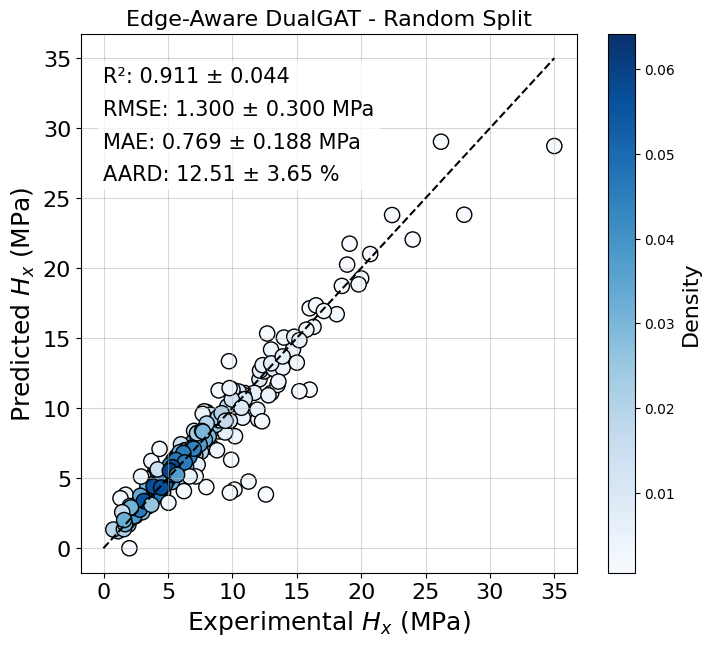

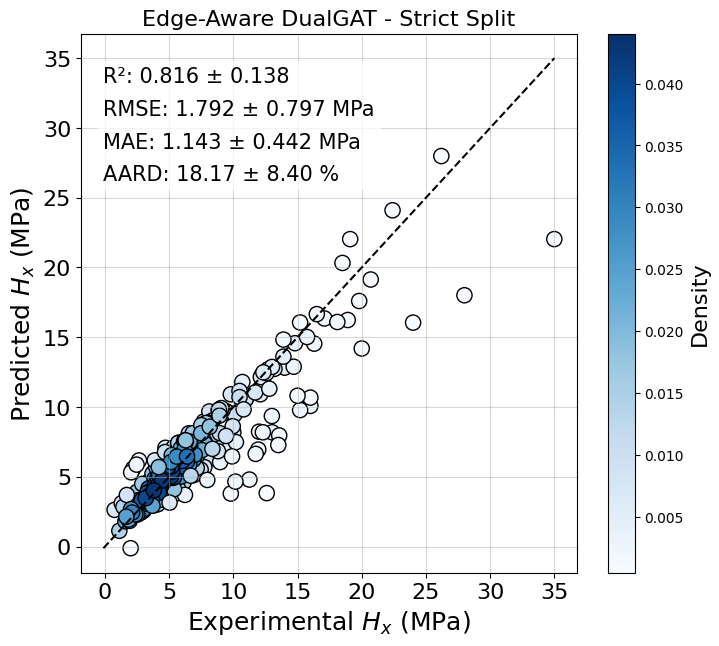

In [ ]:
scatter_density_plot(
    result_gat_random,
    "Edge-Aware DualGAT - Random Split"
)
scatter_density_plot(
    result_gat_strict,
    "Edge-Aware DualGAT - Strict Split"
)

In [ ]:
def residual_plot(result, title):

    y_true = result["Targets"]
    y_pred = result["Predictions"]
    residuals = y_pred - y_true

    plt.figure(figsize=(7, 5))

    plt.scatter(
        y_true,
        residuals,
        alpha=0.8,
        edgecolor="k"
    )

    plt.axhline(
        0,
        linestyle="--",
        color="black"
    )

    plt.xlabel("Experimental Hx (MPa)")
    plt.ylabel("Residuals: Predicted - Experimental")
    plt.title(title)
    plt.grid(alpha=0.4)

    plt.show()

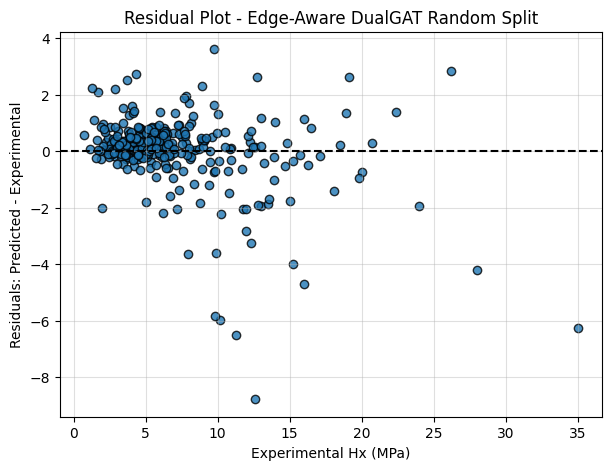

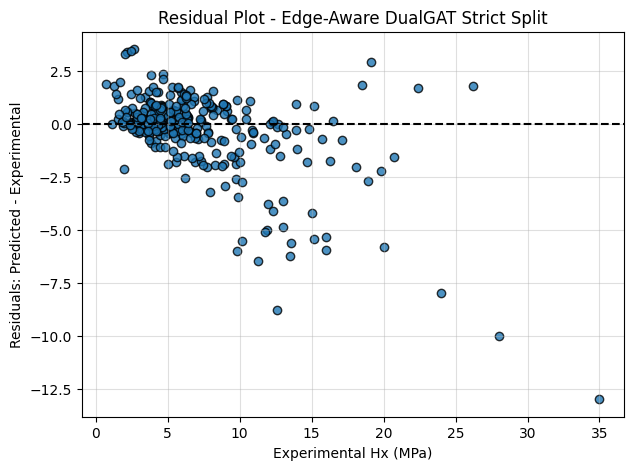

In [ ]:
residual_plot(
    result_gat_random,
    "Residual Plot - Edge-Aware DualGAT Random Split"
)

residual_plot(
    result_gat_strict,
    "Residual Plot - Edge-Aware DualGAT Strict Split"
)

#STRICT_backup

In [ ]:
groups = df_ils["SMILES_IL"]

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(df_ils, groups=groups)
)

print("Train:", len(train_idx))
print("Test:", len(test_idx))

Train: 260
Test: 51


In [ ]:
train_dataset = [
    graph_dataset[i]
    for i in train_idx
]

test_dataset = [
    graph_dataset[i]
    for i in test_idx
]

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))

Train size: 260
Test size: 51


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    collate_fn=lambda x: x
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    collate_fn=lambda x: x
)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import GCNConv, GATv2Conv

import torch.nn as nn

class DualGCNModel(nn.Module):

    def __init__(self):

        super(DualGCNModel, self).__init__()

        # CATION ENCODER
        self.cat_conv1 = GCNConv(8, 64)
        self.cat_conv2 = GCNConv(64, 64)

        # ANION ENCODER
        self.an_conv1 = GCNConv(8, 64)
        self.an_conv2 = GCNConv(64, 64)

        # FUSION
        self.fc1 = nn.Linear(129, 64)
        self.fc2 = nn.Linear(64, 1)

    def encode_graph(self, x, edge_index, conv1, conv2):

        x = conv1(x, edge_index)
        x = F.relu(x)

        x = conv2(x, edge_index)
        x = F.relu(x)

        # GLOBAL POOLING
        x = x.mean(dim=0, keepdim=True)

        return x

    def forward(self, sample):

        # CATION
        x_cat = sample["x_cat"].to(device)
        edge_cat = sample["edge_cat"].to(device)

        # ANION
        x_an = sample["x_an"].to(device)
        edge_an = sample["edge_an"].to(device)

        # TEMPERATURE
        temperature = sample["temperature"].to(device)

        # ENCODE
        cat_embedding = self.encode_graph(
            x_cat,
            edge_cat,
            self.cat_conv1,
            self.cat_conv2
        )

        an_embedding = self.encode_graph(
            x_an,
            edge_an,
            self.an_conv1,
            self.an_conv2
        )

        # FUSION
        x = torch.cat(
            [
                cat_embedding,
                an_embedding,
                temperature
            ],
            dim=1
        )

        x = self.fc1(x)
        x = F.relu(x)

        x = self.fc2(x)

        return x

class ImprovedDualGCN(nn.Module):

    def __init__(self):

        super(ImprovedDualGCN, self).__init__()

        hidden_dim = 128

        # =========================
        # CATION GCN
        # =========================
        self.cat_conv1 = GCNConv(8, hidden_dim)
        self.cat_conv2 = GCNConv(hidden_dim, hidden_dim)
        self.cat_conv3 = GCNConv(hidden_dim, hidden_dim)

        # =========================
        # ANION GCN
        # =========================
        self.an_conv1 = GCNConv(8, hidden_dim)
        self.an_conv2 = GCNConv(hidden_dim, hidden_dim)
        self.an_conv3 = GCNConv(hidden_dim, hidden_dim)

        # =========================
        # FUSION MLP
        # =========================
        self.fc1 = nn.Linear(hidden_dim * 2 + 1, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 1)

    def encode_graph(
        self,
        x,
        edge_index,
        conv1,
        conv2,
        conv3
    ):

        # Layer 1
        x = conv1(x, edge_index)
        x = F.relu(x)

        # Layer 2
        x = conv2(x, edge_index)
        x = F.relu(x)

        # Layer 3
        x = conv3(x, edge_index)
        x = F.relu(x)

        # Dropout
        x = F.dropout(
            x,
            p=0.1,
            training=self.training
        )

        # Global Mean Pooling
        x = x.mean(dim=0, keepdim=True)

        return x

    def forward(self, sample):

        # =========================
        # CATION
        # =========================
        x_cat = sample["x_cat"].to(device)
        edge_cat = sample["edge_cat"].to(device)

        # =========================
        # ANION
        # =========================
        x_an = sample["x_an"].to(device)
        edge_an = sample["edge_an"].to(device)

        # =========================
        # TEMPERATURE
        # =========================
        temperature = sample["temperature"].to(device)

        # =========================
        # ENCODE CATION
        # =========================
        cat_embedding = self.encode_graph(
            x_cat,
            edge_cat,
            self.cat_conv1,
            self.cat_conv2,
            self.cat_conv3
        )

        # =========================
        # ENCODE ANION
        # =========================
        an_embedding = self.encode_graph(
            x_an,
            edge_an,
            self.an_conv1,
            self.an_conv2,
            self.an_conv3
        )

        # =========================
        # FUSION
        # =========================
        x = torch.cat(
            [
                cat_embedding,
                an_embedding,
                temperature
            ],
            dim=1
        )

        # =========================
        # MLP HEAD
        # =========================
        x = self.fc1(x)
        x = F.relu(x)

        x = F.dropout(
            x,
            p=0.1,
            training=self.training
        )

        x = self.fc2(x)
        x = F.relu(x)

        x = self.fc3(x)

        return x

In [ ]:
class DualGAT(nn.Module):

    def __init__(self):

        super(DualGAT, self).__init__()

        hidden_dim = 64
        heads = 4

        # =====================================
        # CATION EDGE-AWARE GAT
        # =====================================
        self.cat_conv1 = GATv2Conv(
            in_channels=8,
            out_channels=hidden_dim,
            heads=heads,
            concat=True,
            edge_dim=7
        )

        self.cat_conv2 = GATv2Conv(
            in_channels=hidden_dim * heads,
            out_channels=hidden_dim,
            heads=1,
            concat=True,
            edge_dim=7
        )

        # =====================================
        # ANION EDGE-AWARE GAT
        # =====================================
        self.an_conv1 = GATv2Conv(
            in_channels=8,
            out_channels=hidden_dim,
            heads=heads,
            concat=True,
            edge_dim=7
        )

        self.an_conv2 = GATv2Conv(
            in_channels=hidden_dim * heads,
            out_channels=hidden_dim,
            heads=1,
            concat=True,
            edge_dim=7
        )

        # =====================================
        # DROPOUT
        # =====================================
        self.dropout = 0.1

        # =====================================
        # MLP HEAD
        # =====================================
        self.fc1 = nn.Linear(
            hidden_dim * 2 + 1,
            128
        )

        self.fc2 = nn.Linear(128, 64)

        self.fc3 = nn.Linear(64, 1)

    def encode_graph(
        self,
        x,
        edge_index,
        edge_attr,
        conv1,
        conv2
    ):

        # =====================================
        # LAYER 1
        # =====================================
        x = conv1(
            x,
            edge_index,
            edge_attr
        )

        x = F.elu(x)

        # =====================================
        # LAYER 2
        # =====================================
        x = conv2(
            x,
            edge_index,
            edge_attr
        )

        x = F.elu(x)

        # =====================================
        # DROPOUT
        # =====================================
        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        # =====================================
        # GLOBAL MEAN POOLING
        # =====================================
        x = x.mean(dim=0, keepdim=True)

        return x

    def forward(self, sample):

        # =====================================
        # CATION
        # =====================================
        x_cat = sample["x_cat"].to(device)

        edge_cat = sample["edge_cat"].to(device)

        edge_attr_cat = sample[
            "edge_attr_cat"
        ].to(device)

        # =====================================
        # ANION
        # =====================================
        x_an = sample["x_an"].to(device)

        edge_an = sample["edge_an"].to(device)

        edge_attr_an = sample[
            "edge_attr_an"
        ].to(device)

        # =====================================
        # TEMPERATURE
        # =====================================
        temperature = sample[
            "temperature"
        ].to(device)

        # =====================================
        # ENCODE CATION
        # =====================================
        cat_embedding = self.encode_graph(
            x_cat,
            edge_cat,
            edge_attr_cat,
            self.cat_conv1,
            self.cat_conv2
        )

        # =====================================
        # ENCODE ANION
        # =====================================
        an_embedding = self.encode_graph(
            x_an,
            edge_an,
            edge_attr_an,
            self.an_conv1,
            self.an_conv2
        )

        # =====================================
        # FUSION
        # =====================================
        x = torch.cat(
            [
                cat_embedding,
                an_embedding,
                temperature
            ],
            dim=1
        )

        # =====================================
        # MLP HEAD
        # =====================================
        x = self.fc1(x)

        x = F.relu(x)

        x = F.dropout(
            x,
            p=self.dropout,
            training=self.training
        )

        x = self.fc2(x)

        x = F.relu(x)

        x = self.fc3(x)

        return x


In [ ]:
# =========================================
# DEVICE
# =========================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)


cpu


In [ ]:

# =========================================
# TRAIN FUNCTION
# =========================================

def train(model, optimizer):

    model.train()

    total_loss = 0

    for batch in train_loader:

        optimizer.zero_grad()

        batch_losses = []

        for sample in batch:

            output = model(sample)

            target = sample["y"].to(device)

            loss = criterion(output, target)

            batch_losses.append(loss)

        loss = torch.stack(batch_losses).mean()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)



In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

def run_cross_validation_experiment(
    model_class,
    model_name,
    lr=0.001,
    epochs=100,
    n_splits=5
):
    print("\n")
    print("=" * 60)
    print(f"CROSS VALIDATION: {model_name}")
    print("=" * 60)

    # =====================================
    # KFOLD
    # =====================================
    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    # =====================================
    # STORE METRICS
    # =====================================
    r2_scores = []
    rmse_scores = []
    mae_scores = []
    aard_scores = []

    # =====================================
    # LOOP FOLDS
    # =====================================
    for fold, (train_idx, test_idx) in enumerate(
        kf.split(graph_dataset)
    ):

        print("\n")
        print(f"Fold {fold+1}/{n_splits}")

        # =====================================
        # SPLIT DATASET
        # =====================================
        train_dataset = [
            graph_dataset[i]
            for i in train_idx
        ]

        test_dataset = [
            graph_dataset[i]
            for i in test_idx
        ]

        # =====================================
        # DATALOADER
        # =====================================
        train_loader = DataLoader(
            train_dataset,
            batch_size=32,
            shuffle=True,
            collate_fn=lambda x: x
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=32,
            shuffle=False,
            collate_fn=lambda x: x
        )

        # =====================================
        # MODEL
        # =====================================
        model = model_class().to(device)

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=lr
        )

        criterion = nn.MSELoss()

        # =====================================
        # TRAINING
        # =====================================
        best_r2 = -999
        best_rmse = None
        best_mae = None
        best_aard = None

        for epoch in range(epochs):

            # TRAIN
            model.train()

            total_loss = 0

            for batch in train_loader:

                optimizer.zero_grad()

                batch_losses = []

                for sample in batch:

                    output = model(sample)

                    target = sample["y"].to(device)

                    loss = criterion(output, target)

                    batch_losses.append(loss)

                loss = torch.stack(batch_losses).mean()

                loss.backward()

                optimizer.step()

                total_loss += loss.item()

            # =====================================
            # EVALUATION
            # =====================================
            model.eval()

            predictions = []
            targets = []

            with torch.no_grad():

                for batch in test_loader:

                    for sample in batch:

                        output = model(sample)

                        predictions.extend(
                            output.cpu().numpy().flatten()
                        )

                        targets.extend(
                            sample["y"].cpu().numpy().flatten()
                        )

            r2 = r2_score(targets, predictions)

            rmse = np.sqrt(
                mean_squared_error(
                    targets,
                    predictions
                )
            )

            mae = mean_absolute_error(
                targets,
                predictions
            )

            # Calculate AARD
            # Avoid division by zero for targets that are 0
            # For chemical properties, targets should ideally not be zero
            # Added a small epsilon to prevent potential issues, though unlikely for Henry's Constant
            aard = np.mean(np.abs((np.array(targets) - np.array(predictions)) / (np.array(targets) + 1e-6))) * 100

            # SAVE BEST
            if r2 > best_r2:

                best_r2 = r2
                best_rmse = rmse
                best_mae = mae
                best_aard = aard

        # =====================================
        # SAVE FOLD RESULT
        # =====================================

        r2_scores.append(best_r2)
        rmse_scores.append(best_rmse)
        mae_scores.append(best_mae)
        aard_scores.append(best_aard)

        print(
            f"Best Fold R2: {best_r2:.4f}"
            f" | RMSE: {best_rmse:.4f}"
            f" | MAE: {best_mae:.4f}"
            f" | AARD: {best_aard:.4f}"
        )

    # =====================================
    # FINAL RESULT
    # =====================================

    print("\n")
    print("=" * 60)
    print(f"FINAL RESULT: {model_name}")
    print("=" * 60)

    print(
        f"R² = "
        f"{np.mean(r2_scores):.3f} "
        f"± {np.std(r2_scores):.3f}"
    )

    print(
        f"RMSE = "
        f"{np.mean(rmse_scores):.3f} "
        f"± {np.std(rmse_scores):.3f}"
    )

    print(
        f"MAE = "
        f"{np.mean(mae_scores):.3f} "
        f"± {np.std(mae_scores):.3f}"
    )

    print(
        f"AARD = "
        f"{np.mean(aard_scores):.3f} "
        f"± {np.std(aard_scores):.3f}"
    )

    return {
        "Model": model_name,

        "R2 Mean": np.mean(r2_scores),
        "R2 Std": np.std(r2_scores),

        "RMSE Mean": np.mean(rmse_scores),
        "RMSE Std": np.std(rmse_scores),

        "MAE Mean": np.mean(mae_scores),
        "MAE Std": np.std(mae_scores),

        "AARD Mean": np.mean(aard_scores),
        "AARD Std": np.std(aard_scores)
    }

In [ ]:
results = []

# =====================================
# DualGCN
# =====================================

result_gcn = run_cross_validation_experiment(
    model_class=DualGCNModel,
    model_name="DualGCNModel",
    lr=0.001,
    epochs=100,
    n_splits=5
)

results.append(result_gcn)

# =====================================
# ImprovedDualGCN
# =====================================

result_improved = run_cross_validation_experiment(
    model_class=ImprovedDualGCN,
    model_name="ImprovedDualGCN",
    lr=0.001,
    epochs=100,
    n_splits=5
)

results.append(result_improved)

# =====================================
# DualGAT
# =====================================

result_gat = run_cross_validation_experiment(
    model_class=DualGAT,
    model_name="DualGAT",
    lr=0.0005,
    epochs=100,
    n_splits=5
)

results.append(result_gat)

# =====================================
# FINAL TABLE
# =====================================

results_df = pd.DataFrame(results)

print("\n")
print("=" * 60)
print("FINAL COMPARISON")
print("=" * 60)

print(results_df)



CROSS VALIDATION: DualGCNModel


Fold 1/5
Best Fold R2: 0.8142 | RMSE: 1.9330 | MAE: 1.1284 | AARD: 23.9846


Fold 2/5
Best Fold R2: 0.6715 | RMSE: 2.3638 | MAE: 1.4256 | AARD: 34.9838


Fold 3/5
Best Fold R2: 0.6741 | RMSE: 2.3029 | MAE: 1.6840 | AARD: 33.3740


Fold 4/5
Best Fold R2: 0.6199 | RMSE: 3.7404 | MAE: 1.8113 | AARD: 24.6280


Fold 5/5
Best Fold R2: 0.7067 | RMSE: 2.4840 | MAE: 2.0741 | AARD: 38.4203


FINAL RESULT: DualGCNModel
R² = 0.697 ± 0.065
RMSE = 2.565 ± 0.616
MAE = 1.625 ± 0.324
AARD = 31.078 ± 5.768


CROSS VALIDATION: ImprovedDualGCN


Fold 1/5
Best Fold R2: 0.9418 | RMSE: 1.0814 | MAE: 0.7307 | AARD: 13.0396


Fold 2/5
Best Fold R2: 0.7718 | RMSE: 1.9702 | MAE: 1.2422 | AARD: 29.8561


Fold 3/5
Best Fold R2: 0.8238 | RMSE: 1.6933 | MAE: 1.0375 | AARD: 19.2509


Fold 4/5
Best Fold R2: 0.8154 | RMSE: 2.6067 | MAE: 1.4787 | AARD: 24.5543


Fold 5/5
Best Fold R2: 0.7881 | RMSE: 2.1114 | MAE: 1.5469 | AARD: 27.7879


FINAL RESULT: ImprovedDualGCN
R² = 0.828 ± 0.060

#command


In [ ]:
#Random splitting

In [ ]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
Y_pred, Y_true = [], []
r2_scores, rmse_scores, mae_scores, aards = [], [], [], []

for train_index, test_index in cv.split(X):
    x_train = X.loc[train_index].values
    x_test = X.loc[test_index].values
    y_train = y[train_index]
    y_test = y[test_index]

    rf = CatBoostRegressor(silent=True, iterations= 905, depth = 3, learning_rate = 0.21624738569732568, subsample=0.44167363309173513)
    rf.fit(x_train, y_train)
    y_pred = rf.predict(x_test)

    Y_pred.extend(y_pred)
    Y_true.extend(y_test)

    r2_scores.append(metrics.r2_score(y_test, y_pred))
    rmse_scores.append(metrics.mean_squared_error(y_test, y_pred))
    mae_scores.append(mean_absolute_error(y_test, y_pred))

    relative_deviation = (y_test - y_pred) / y_test
    absolute_relative_deviation = abs(relative_deviation)
    average_relative_deviation = absolute_relative_deviation.mean() * 100
    aards.append(average_relative_deviation)

print('R^2 = {} ± {}'.format(round(np.mean(r2_scores), 3), round(np.std(r2_scores), 3)))
print('RMSE = {} ± {}'.format(round(np.mean(rmse_scores), 3), round(np.std(rmse_scores), 3)))
print('MAE = {} ± {}'.format(round(np.mean(mae_scores), 3), round(np.std(mae_scores), 3)))
print('AARD = {} ± {}'.format(round(np.mean(aards), 3), round(np.std(aards), 3)))

R^2 = 0.932 ± 0.018
RMSE = 2.125 ± 0.946
MAE = 0.82 ± 0.126
AARD = 11.335 ± 1.633


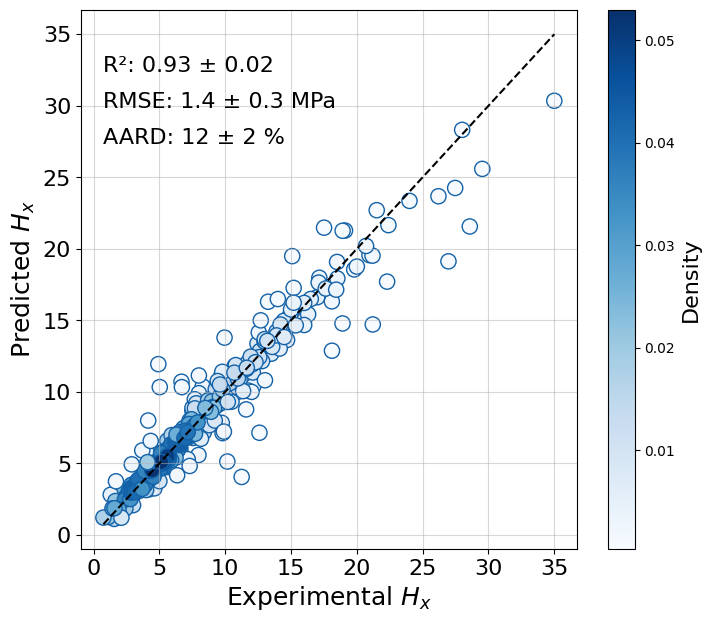

In [ ]:
from scipy.stats import gaussian_kde


experimental = np.array(Y_true)
predicted = np.array(Y_pred)
errors = predicted - experimental

def calculate_aard(experimental, predicted):
    relative_errors = np.abs((experimental - predicted) / experimental)
    aard = np.mean(relative_errors) * 100
    return aard

def scatter_density_plot(experimental, predicted):

    xy = np.vstack([experimental, predicted])
    z = gaussian_kde(xy)(xy)


    plt.figure(figsize=(8, 7))
    plt.subplot(1, 1, 1)
    scatter = plt.scatter(experimental, predicted, c=z, s=120, cmap='Blues', alpha=1, edgecolor='#1361a7')
    cbar = plt.colorbar(scatter)
    cbar.set_label('Density', fontsize=16)

    plt.yticks(fontsize=16)
    plt.xticks(fontsize=16)

    plt.plot([min(experimental), max(experimental)], [min(experimental), max(experimental)], 'k--')

    plt.xlabel(r'Experimental $H_x$', fontsize=18)
    plt.ylabel(r'Predicted $H_x$', fontsize=18)
    plt.grid(True, alpha=0.5)
    plt.text(min(experimental), max(predicted) - 3, f'R²: 0.93 ± 0.02 \nRMSE: 1.4 ± 0.3 MPa \nAARD: 12 ± 2 %', fontsize=16, linespacing=2)

scatter_density_plot(experimental, predicted)

In [ ]:
#Strict splitting

In [ ]:
class UniqueGroupKFold:
    def __init__(self, n_splits=5, shuffle=False, random_state=None):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def split(self, X, y=None, groups=None):
        unique_groups = np.unique(groups)
        if self.shuffle:
            np.random.seed(self.random_state)
            np.random.shuffle(unique_groups)

        fold_size = len(unique_groups) // self.n_splits

        for i in range(self.n_splits):
            if i == self.n_splits - 1:
                test_groups = unique_groups[i * fold_size:]
            else:
                test_groups = unique_groups[i * fold_size: (i + 1) * fold_size]

            test_indices = np.where(np.isin(groups, test_groups))[0]
            train_indices = np.where(~np.isin(groups, test_groups))[0]

            if len(test_indices) > 0 and len(train_indices) > 0:
                yield train_indices, test_indices

In [ ]:
cv = UniqueGroupKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
s =pd.concat([df_ils["SMILES_IL"], selected_dess["SMILES_DES"]], axis=0, ignore_index=True)

In [ ]:
Y_pred, Y_true = [], []
r2_scores, rmse_scores, mae_scores, aards = [], [], [], []

for train_index, test_index in cv.split(X, groups=s):
    x_train = X.loc[train_index].values
    x_test = X.loc[test_index].values
    y_train = y[train_index]
    y_test = y[test_index]

    rf = CatBoostRegressor(silent=True)
    rf.fit(x_train, y_train)
    y_pred = rf.predict(x_test)


    Y_pred.extend(y_pred)
    Y_true.extend(y_test)


    r2_scores.append(metrics.r2_score(y_test, y_pred))
    rmse_scores.append(metrics.mean_squared_error(y_test, y_pred))
    mae_scores.append(mean_absolute_error(y_test, y_pred))


    relative_deviation = (y_test - y_pred) / y_test
    absolute_relative_deviation = abs(relative_deviation)
    average_relative_deviation = absolute_relative_deviation.mean() * 100
    aards.append(average_relative_deviation)


print('R^2 = {} ± {}'.format(round(np.mean(r2_scores), 3), round(np.std(r2_scores), 3)))
print('RMSE = {} ± {}'.format(round(np.mean(rmse_scores), 3), round(np.std(rmse_scores), 3)))
print('MAE = {} ± {}'.format(round(np.mean(mae_scores), 3), round(np.std(mae_scores), 3)))
print('AARD = {} ± {}'.format(round(np.mean(aards), 3), round(np.std(aards), 3)))

R^2 = 0.718 ± 0.148
RMSE = 9.48 ± 8.06
MAE = 1.713 ± 0.615
AARD = 22.687 ± 2.749


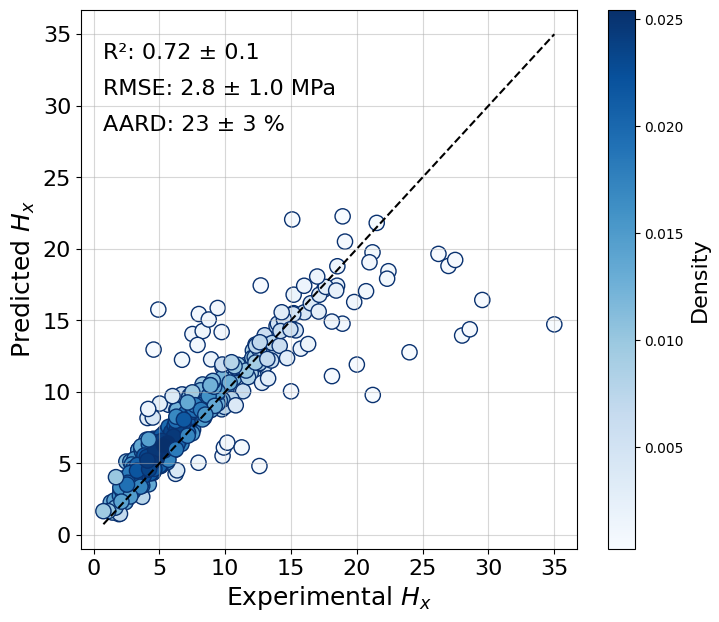

In [ ]:
from scipy.stats import gaussian_kde

experimental = np.array(Y_true)
predicted = np.array(Y_pred)
errors = predicted - experimental

def calculate_aard(experimental, predicted):
    relative_errors = np.abs((experimental - predicted) / experimental)
    aard = np.mean(relative_errors) * 100
    return aard

def scatter_density_plot(experimental, predicted):

    xy = np.vstack([experimental, predicted])
    z = gaussian_kde(xy)(xy)
    plt.figure(figsize=(8, 7))


    plt.subplot(1, 1, 1)
    scatter = plt.scatter(experimental, predicted, c=z, s=120, cmap='Blues', alpha=1, edgecolor='#09316f')
    cbar = plt.colorbar(scatter)
    cbar.set_label('Density', fontsize=16)

    plt.yticks(fontsize=16)
    plt.xticks(fontsize=16)


    plt.plot([min(experimental), max(experimental)], [min(experimental), max(experimental)], 'k--')

    plt.xlabel(r'Experimental $H_x$', fontsize=18)
    plt.ylabel(r'Predicted $H_x$', fontsize=18)
    plt.grid(True, alpha=0.5)
    plt.text(min(experimental), max(predicted) + 6, f'R²: 0.72 ± 0.1 \nRMSE: 2.8 ± 1.0 MPa \nAARD: 23 ± 3 %', fontsize=16, linespacing=2)
scatter_density_plot(experimental, predicted)

In [ ]:
from sklearn.preprocessing import StandardScaler
import shap

n_samples = X.shape[0]

all_leverages = np.zeros(n_samples)
all_residuals = np.zeros(n_samples)

X=X.values

for fold, (train_idx, test_idx) in enumerate(cv.split(X, groups=s)):
    print(f' fold {fold+1}/5...')
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]


    model = CatBoostRegressor(verbose=0)
    model.fit(X_train, y_train)


    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)


    shap_matrix = np.abs(shap_values)
    leverage_shap = shap_matrix.sum(axis=1)


    y_pred = model.predict(X_test)
    residuals = y_test - y_pred
    std_residuals = residuals / np.std(residuals)


    all_leverages[test_idx] = leverage_shap
    all_residuals[test_idx] = std_residuals

 fold 1/5...
 fold 2/5...
 fold 3/5...
 fold 4/5...
 fold 5/5...


In [ ]:
h_star = np.percentile(all_leverages, 95)
out_of_leverage = np.sum(all_leverages > h_star)
out_of_residuals = np.sum((all_residuals < -3) | (all_residuals > 3))

print(f'Number of points outside the SHAP lever threshold (L*): {out_of_leverage}')
print(f'Number of points outside the boundaries of standardized residuals (±3): {out_of_residuals}')

Number of points outside the SHAP lever threshold (L*): 19
Number of points outside the boundaries of standardized residuals (±3): 7


/tmp/ipykernel_7740/712541938.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(


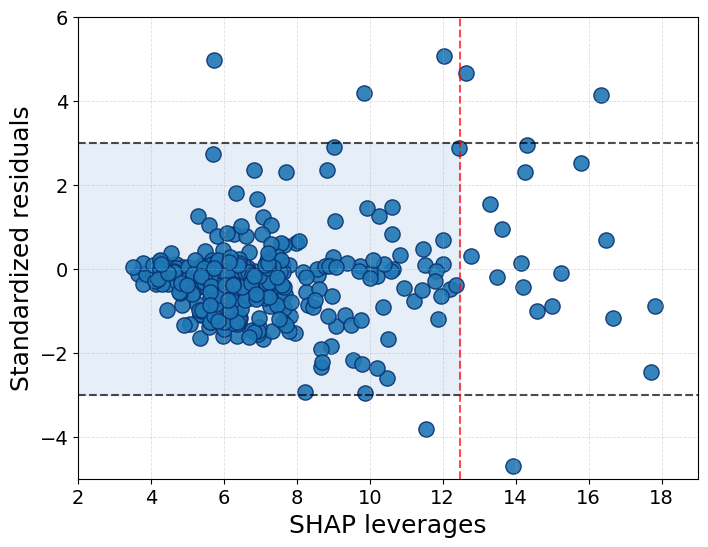

In [ ]:
plt.figure(figsize=(8, 6))


plt.fill_between(
    x=[0, h_star],
    y1=-3,
    y2=3,
    color='#cedff1',
    alpha=0.5
)
plt.scatter(
    all_leverages,
    all_residuals,
    s=120,
    cmap='Blues',
    edgecolors='#09316f',
    linewidth=1,
    alpha=0.9
)
plt.axhline(y=3, color='black', linestyle='--', alpha=0.7)
plt.axhline(y=-3, color='black', linestyle='--', alpha=0.7)
plt.axvline(x=h_star, color='red', linestyle='--', alpha=0.7)
plt.xlabel('SHAP leverages',fontsize=18)
plt.ylabel('Standardized residuals', fontsize=18)

plt.grid(True, linestyle='--', linewidth=0.6, alpha=0.4)
plt.xlim(2, 19)
plt.ylim(-5, 6)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.show()